# **Artificial Neural Network Using House Data**

**1.Import Required Libraries**

Load all necessaryPython librarires such as Pandas, NumPy, Scikit-Learn and TensorFlow for data processing and model building.

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

**2.Load the Dataset**

Read the housing dataset using Pandas.

In [14]:
# Load dataset
df = pd.read_csv("house_data.csv")

In [15]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

**3.Feature Selection**

- Select important numerical features from the dataset that influence house price.

- Apply log transformation to the target variable (price) to reduce skewness and improve model training stability.

- House prices are usually highly skewed

- Log transformation makes the distribution more normal

In [24]:
# Select better features
X = df[['bedrooms','bathrooms','floors','sqft_living','sqft_lot',
        'view','condition','sqft_above','sqft_basement','yr_built']]

# Log Transform Target
y = np.log1p(df['price'])


**4. Train-Test-Split**

Split the dataset into training and testing data.

- 80% training data

- 20% testing data

In [25]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**5.Feature Selection**

Normalize the features using StandardScaler.

In [26]:
# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**6.Build artificial Neural Network Model**

Create a Deep Learning model using TensorFlow.

Model Architecture:

- Input Layer

- Hidden Layers

- Dropout Layer (for regularization)

- Output Layer

In [27]:
# Build ANN Model
model = Sequential()

# Input Layer + Hidden Layer
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))

# Dropout to reduce overfitting
model.add(Dropout(0.3))

# Hidden Layer
model.add(Dense(64, activation='relu'))

# Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**7.Complie the Model**

Configure the learning process.

| Component | Purpose |
|-----------|---------|
| Adam Optimizer | Efficient gradient optimization |
| MSE Loss | Measures prediction error |
| MAE Metric | Measures average prediction difference |

In [28]:
# Compile model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

**8.Train the Model**

Train the neural network using the training dataset.

| Parameter | Meaning |
|-----------| -------- |
| Epochs   | Number of training cycles |
| Batch Size | Data processed per iteration |
| Validation Split | Used to monitor overfitting |

In [29]:
# Train model
history = model.fit(X_train, y_train, epochs=100, batch_size=32,validation_split=0.2)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 114.1073 - mae: 9.9157 - val_loss: 8.5430 - val_mae: 2.2386
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.0700 - mae: 2.3028 - val_loss: 6.4339 - val_mae: 1.9391
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7.8564 - mae: 1.9451 - val_loss: 4.0332 - val_mae: 1.3284
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4716 - mae: 1.6266 - val_loss: 3.6517 - val_mae: 1.2776
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.8958 - mae: 1.5604 - val_loss: 2.9788 - val_mae: 1.0633
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9612 - mae: 1.3363 - val_loss: 2.6776 - val_mae: 0.9551
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.5579 - mae: 1.3248 - val_loss: 2.3400 - val_mae: 0.7965
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.4892 - mae: 1.2922 - val_loss: 2.2470 - val_mae: 0.8418
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.

**9.Model Evaluation**

Evaluate model performance on unseen test data.

In [30]:
# Evaluate model
loss, mae = model.evaluate(X_test, y_test)

print("Test MAE:", mae)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7324 - mae: 0.6622
Test MAE: 0.5962870121002197


**10. Model Training Performance(Loss vs Epochs)**

To evaluate how well the Artificial Neural Network (ANN) learns during training, we visualize the training loss and validation loss using Matplotlib.

This helps us understand:

- How the model is learning over time

- Whether the model is overfitting or underfitting

- If the training process is stable

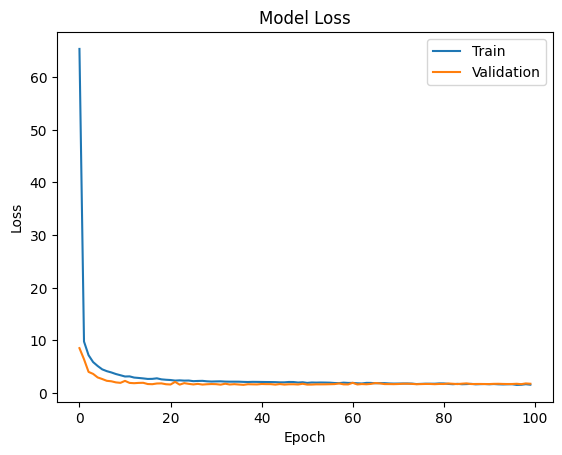

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])
plt.show()

**11. Model Prediction and Price Conversion**

- After training the Artificial Neural Network (ANN) model, predictions are generated on the test dataset to evaluate how well the model performs on unseen data.

- Since the target variable (house price) was transformed using log transformation (log1p) during training, the predicted values must be converted back to their original scale using exponential transformation (expm1).

In [33]:
# Make Predictions
pred = model.predict(X_test)

# Convert log values back to actual prices
pred_price = np.expm1(pred)
actual_price = np.expm1(y_test)

# Create comparison table
results = pd.DataFrame({
    "Actual Price": actual_price.values[:10],
    "Predicted Price": pred_price.flatten()[:10]
})

# Print comparison
print("📊 Actual vs Predicted House Prices (First 10 Rows)")
print(results)

# Optional: Show prediction samples
print("\n🔹 Sample Raw Model Predictions (Log Scale):")
print(pred[:5])

print("\n🔹 Converted Predicted Prices:")
print(pred_price[:5])

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
📊 Actual vs Predicted House Prices (First 10 Rows)
   Actual Price  Predicted Price
0  5.440000e+05    294833.000000
1  0.000000e+00    246455.515625
2  1.712500e+06    508030.625000
3  3.650000e+05    299796.281250
4  2.750000e+05    276170.968750
5  6.250000e+05    423449.937500
6  4.530000e+05    276581.343750
7  3.000000e+05    307249.000000
8  4.179857e+05    368524.968750
9  6.725000e+05    385832.062500

🔹 Sample Raw Model Predictions (Log Scale):
[[12.594168]
 [12.414941]
 [13.138299]
 [12.610862]
 [12.528779]]

🔹 Converted Predicted Prices:
[[294833.  ]
 [246455.52]
 [508030.62]
 [299796.28]
 [276170.97]]


** Result Interpretation**

- Compare actual house prices with model predictions

- Evaluate how close the ANN model predictions are to real values

- Understand the effectiveness of the log transformation

A comparison table is created to display the first 10 predicted values alongside actual prices, making it easier to analyze model performance.